# Systematic Experimentation Framework
**FEATURE CATALOG · MODEL CATALOG · MODELTRACKER**

---

## Content

- [Setup](#setup)
- [The feature catalog](#the-feature-catalog)
- [The model catalog](#the-model-catalog)
- [The `ModelTracker`](#the-modeltracker)
- [Live demo — a mini sweep](#live-demo-a-mini-sweep)
- [The real 448-run benchmark](#the-real-448-run-benchmark)
- [From benchmark to champion](#from-benchmark-to-champion)

**Wie der Champion gefunden wurde: ein Feature-Catalog, ein Model-Catalog und ein selbstgebauter Experiment-Tracker.**

Statt Modelle ad-hoc zu trainieren, fährt dieses Projekt einen **systematischen Sweep** über
*Feature-Sets × Modell-Familien* und protokolliert jeden Run. Dieses Notebook zeigt diese
Infrastruktur — das Engineering-Handwerk hinter den Ergebnissen, nicht nur die finalen Zahlen.

**Komponenten**
- `config_features_catalog.py` — wiederverwendbare Feature-Sets, gruppiert nach Risiko-Hypothese
- `config_models_catalog.py` — Modell-Familien mit fixen, vergleichbaren Konfigurationen
- `ModelTracker` — ein schlanker Experiment-Logger (CSV-Log · smarter Modell-Export · Best-Run-Flag)

## Setup

In [1]:
import warnings; warnings.filterwarnings('ignore')
import io, contextlib, tempfile, pandas as pd, numpy as np
import matplotlib.pyplot as plt
import us_used_vehicle_resales as wg
from us_used_vehicle_resales.cleaning import clean_data
from us_used_vehicle_resales.features import engineer_features
from us_used_vehicle_resales.config_features_catalog import features_catalog
from us_used_vehicle_resales.config_models_catalog import models_catalog
pd.set_option('display.max_colwidth', 60)

def _quiet(fn,*a,**k):
    with contextlib.redirect_stdout(io.StringIO()): return fn(*a,**k)

## The feature catalog

Features sind nach **Risiko-Hypothese** (Preis, Nutzung, Garantie, Region, …) zu wiederverwendbaren Sets gruppiert. Der Sweep kann dann ein Set beim Namen referenzieren — `baseline`, `all_in_with_noise`, `cats_strong` — statt Spaltenlisten hart zu codieren. Das hält Experimente deklarativ und vergleichbar.

In [2]:
catalog = {name: feats for name, feats in features_catalog.items() if isinstance(feats, list)}
overview = pd.DataFrame([
    {'feature_set': name,
     'n_features': len(feats),
     'has_engineered': any(f.startswith('feat_') for f in feats),
     'example_members': ', '.join(feats[:4]) + (' …' if len(feats) > 4 else '')}
    for name, feats in catalog.items()
]).sort_values('n_features', ascending=False).reset_index(drop=True)
print(f"{len(catalog)} named feature sets, from {overview.n_features.min()} to {overview.n_features.max()} features")
overview

19 named feature sets, from 3 to 41 features


,feature_set,n_features,has_engineered,example_members
0,all_in,41,True,"PurchDate, Auction, VehYear, VehicleAge …"
1,all_in_with_noise,28,True,"VehicleAge, VehOdo, VehBCost, WarrantyCost …"
2,log_reg_set_01,19,True,"VehOdo, VehBCost, WarrantyCost, VehicleAge …"
3,price,12,True,"MMRAcquisitionAuctionAveragePrice, MMRAcquisitionAuction..."
4,modern_engineered_only,10,True,"feat_miles_per_year, feat_price_ratio, feat_price_diff, ..."
5,champion_v1,10,True,"VNZIP1, Trim, SubModel, Make …"
6,baseline,8,True,"VehicleAge, VehOdo, VehBCost, MMRAcquisitionAuctionAvera..."
7,baseline_classic,7,False,"VehicleAge, VehOdo, VehBCost, WarrantyCost …"
8,cats_strong,7,False,"Make, Model, Trim, SubModel …"
9,high_impact_categories,7,False,"Make, Model, Trim, SubModel …"


## The model catalog

Jede Modell-Familie ist mit fixen Hyperparametern vorkonfiguriert, sodass sich ein Run nur darin unterscheidet, *welches* Modell und *welches* Feature-Set verwendet wird — ein sauberer, kontrollierter Vergleich. Alle Klassifikatoren nutzen `class_weight='balanced'`, um der 12%-Positivrate entgegenzuwirken.

In [3]:
def key_params(est):
    keep = ['penalty','l1_ratio','C','solver','n_estimators','max_depth',
            'min_samples_leaf','learning_rate','max_iter','l2_regularization']
    p = est.get_params()
    return ', '.join(f"{k}={p[k]}" for k in keep if k in p and p[k] is not None)

models_tbl = pd.DataFrame([
    {'model': name, 'estimator': type(est).__name__, 'key_params': key_params(est)}
    for name, est in models_catalog.items()
])
models_tbl

,model,estimator,key_params
0,log_reg_balanced,LogisticRegression,"penalty=elasticnet, l1_ratio=0, C=1.0, solver=saga, max_..."
1,log_reg_lasso,LogisticRegression,"penalty=elasticnet, l1_ratio=1, C=0.1, solver=saga, max_..."
2,rf_shallow,RandomForestClassifier,"n_estimators=100, max_depth=7, min_samples_leaf=1"
3,rf_deep,RandomForestClassifier,"n_estimators=200, max_depth=15, min_samples_leaf=5"
4,hist_boost_std,HistGradientBoostingClassifier,"max_depth=5, min_samples_leaf=20, learning_rate=0.1, max..."
5,hist_boost_aggressive,HistGradientBoostingClassifier,"max_depth=10, min_samples_leaf=20, learning_rate=0.05, m..."


## The `ModelTracker`

Ein selbstgebauter Experiment-Logger. Pro Run berechnet er F1 / Recall / Precision / ROC-AUC, hängt an ein **persistentes CSV** an, flaggt einen **neuen Bestwert** und macht einen **Smart Export** — er picklet die gefittete Pipeline nur, wenn der Run es wert ist (F1 ≥ 0,30 oder neuer Bestwert), damit die Platte nicht mit schwachen Modellen vollläuft.

In [4]:
import inspect
print(inspect.getsource(wg.ModelTracker.add_entry).split('return')[0])

    def add_entry(self, model_name, model_obj, features_name, features_list, y_true, y_pred, y_proba=None, description=""):
        # 1. Metriken
        f1 = f1_score(y_true, y_pred)
        rec = recall_score(y_true, y_pred)
        prec = precision_score(y_true, y_pred)
        auc = roc_auc_score(y_true, y_proba) if y_proba is not None else 0.0
        
        current_idx = len(self.results)
        
        # 2. Prüfen: Ist das ein neuer Bestwert?
        current_best_f1 = 0.0
        if self.results:
            current_best_f1 = max([r.get('F1-Score', 0) for r in self.results])
        
        is_best = f1 > current_best_f1
        is_worthy = f1 >= 0.30  # Deine magische Grenze
        
        # 3. Eintrag erstellen
        filename_short = f"{str(current_idx).zfill(3)}_{model_name}"
        # Wir merken uns in der CSV, ob ein File existiert
        file_saved = "No" 
        
        # 4. Nur speichern, wenn es sich lohnt (Smart Export)
        if is_best or is_worthy:
    

## Live demo — a mini sweep

Um den Mechanismus zu zeigen (nicht alle 448 Runs zu reproduzieren), sweepen wir ein paar Modelle über das `baseline`-Feature-Set und lassen den Tracker sie loggen. Der Tracker schreibt in einen Wegwerf-Pfad, damit das echte Log unangetastet bleibt.

In [5]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# prepared train/val (same cleaning + FE chain as the rest of the project)
X = _quiet(engineer_features, _quiet(clean_data, pd.read_parquet('../data/02_interim/features_train.parquet')), print_status=False)
y = pd.read_parquet('../data/02_interim/target_train.parquet').iloc[:, 0].loc[X.index]
from sklearn.model_selection import train_test_split
Xtr, Xval, ytr, yval = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

def build(feats, model):
    feats = [f for f in feats if f in Xtr.columns]
    num = [f for f in feats if str(Xtr[f].dtype).startswith(('int','float'))]
    cat = [f for f in feats if f not in num]
    pre = ColumnTransformer([('num', StandardScaler(), num),
                             ('cat', OneHotEncoder(handle_unknown='ignore'), cat)])
    return Pipeline([('pre', pre), ('clf', model)]), feats

tracker = wg.ModelTracker(csv_path=tempfile.mkdtemp() + '/demo_runs.csv')  # throwaway
for name in ['log_reg_lasso', 'rf_shallow', 'rf_deep']:
    pipe, feats = build(features_catalog['baseline'], models_catalog[name])
    pipe.fit(Xtr[feats], ytr)
    proba = pipe.predict_proba(Xval[feats])[:, 1]
    tracker.add_entry(model_name=name, model_obj=pipe, features_name='baseline',
                      features_list=feats, y_true=yval, y_pred=(proba >= 0.5).astype(int),
                      y_proba=proba, description='live demo on baseline set')

tracker.get_results()[['Run_ID','Model','F1-Score','Recall','Precision','ROC-AUC','Is_Best','Model_File']]

💾 Modell-Datei erstellt: /var/folders/jh/b553h44j08x_jr8xwh9jbc5r0000gn/T/tmpcj66fe2n/export/000_log_reg_lasso.joblib
ID 0: F1=0.2849 -> 🏆 NEUER BESTWERT & GESPEICHERT


💾 Modell-Datei erstellt: /var/folders/jh/b553h44j08x_jr8xwh9jbc5r0000gn/T/tmpcj66fe2n/export/001_rf_shallow.joblib
ID 1: F1=0.2909 -> 🏆 NEUER BESTWERT & GESPEICHERT


💾 Modell-Datei erstellt: /var/folders/jh/b553h44j08x_jr8xwh9jbc5r0000gn/T/tmpcj66fe2n/export/002_rf_deep.joblib
ID 2: F1=0.2965 -> 🏆 NEUER BESTWERT & GESPEICHERT


,Run_ID,Model,F1-Score,Recall,Precision,ROC-AUC,Is_Best,Model_File
0,0,log_reg_lasso,0.2849,0.6207,0.1849,0.6671,True,export/000_log_reg_lasso.joblib
1,1,rf_shallow,0.2909,0.6345,0.1887,0.6730,True,export/001_rf_shallow.joblib
2,2,rf_deep,0.2965,0.5073,0.2094,0.6721,True,export/002_rf_deep.joblib


## The real 448-run benchmark

Das eigentliche Projekt ist diese Schleife über den vollständigen Catalog gefahren. Das persistente Log unten ist das echte Tracking-CSV — jede Modell-×-Feature-Set-Kombination, die ausprobiert wurde.

447 logged runs


,Run_ID,Model,F1-Score,Recall,Precision
0,438,reconstructed_402_lasso_thresh_0.72,0.4064,0.3439,0.4967
1,433,reconstructed_402_lasso_thresh_0.66,0.4014,0.3863,0.4178
2,431,logreg_lasso_grid_best,0.3814,0.6284,0.2738
3,429,logreg_lasso_grid_best,0.3814,0.6284,0.2738
4,402,log_reg_lasso_all_in_with_noise,0.3801,0.6245,0.2732
5,406,hist_boost_aggressive_all_in_with_noise,0.3756,0.6130,0.2708
6,45,hist_boost_all_in_with_noise,0.3726,0.6029,0.2696
7,427,logreg_lasso_full_buffet,0.3725,0.6376,0.2631
8,419,logreg_lasso_full_buffet,0.3725,0.6376,0.2631
9,426,logreg_lasso_full_buffet,0.3725,0.6376,0.2631


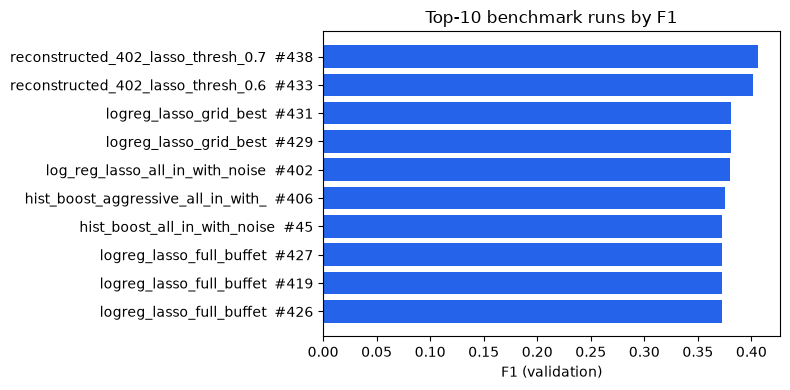

In [6]:
runs = pd.read_csv('../data/04_models/model_results_tracking.csv').dropna(subset=['F1-Score'])
print(f"{len(runs)} logged runs")
top = runs.sort_values('F1-Score', ascending=False).head(10)
display(top[['Run_ID','Model','F1-Score','Recall','Precision']].reset_index(drop=True))

fig, ax = plt.subplots(figsize=(8,4))
t = top[::-1]
ax.barh(t['Model'].str.slice(0,34) + '  #' + t['Run_ID'].astype(str), t['F1-Score'], color='#2563eb')
ax.set_xlabel('F1 (validation)'); ax.set_title('Top-10 benchmark runs by F1'); plt.tight_layout(); plt.show()

## From benchmark to champion

Der Sweep hat **Logistische Regression mit L1-Penalty auf dem grossen Feature-Set** als stärkstes
Recall-orientiertes Modell hervorgebracht — den Champion. Zwei Engineering-Hinweise sind wichtig,
um diese Zahlen ehrlich zu lesen:

- Der Tracker loggt **Validation**-Scores, die für die *Modellauswahl* verwendet werden. Die
  **finalen, vergleichbaren Zahlen** kommen aus der einmaligen Evaluation der gewählten Modelle
  auf einem sauberen Held-out-Test — siehe [`04_evaluation.ipynb`](04_evaluation.ipynb), die
  Ergebnis-Single-Source-of-Truth.
- Mehrere Tree-Runs zeigen hohen F1 bei unbrauchbarem Recall (~0,3); das systematische Log macht
  diesen Trade-off sichtbar, statt ihn hinter einer einzelnen Headline-Metrik zu verstecken.

**Fazit:** Der Wert hier liegt nicht in einem glücklichen Einzelmodell — sondern in einem
*wiederholbaren Framework*, um es zu finden.